# Mini-Proyecto: EDA Visual Completo con Seaborn

En este notebook se realiza un análisis exploratorio de datos visual completo utilizando el dataset de personas ficticio (fake_people_data.csv). Este análisis forma parte del Bloque III del curso y aplica los conceptos de las sesiones 40, 41 y 42.

## Importación de bibliotecas

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Configuración general
sns.set_style("whitegrid")

## Carga y exploración inicial del dataset

In [2]:
df = pd.read_csv("fake_people_data.csv")
print("Dimensiones del dataset:", df.shape)
df.head(10)

Dimensiones del dataset: (10000, 5)


,name,age,height,weight,sex
0,Cody Martinez,56.0,1.85,119.6,F
1,Amanda Fuller DVM,69.0,1.58,87.6,M
2,Aaron Richardson,46.0,1.62,99.7,M
3,Shannon Tran,32.0,1.92,53.9,F
4,Joshua Freeman,60.0,1.60,94.2,F
5,Jessica Jones,25.0,1.54,103.5,M
6,Theresa Smith,38.0,1.85,104.5,M
7,Justin Tucker,56.0,1.70,103.9,M
8,Dylan Hernandez,36.0,1.96,65.8,F
9,Patrick Moss,40.0,1.83,118.3,F


In [3]:
# Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   name    9995 non-null   object 
 1   age     9995 non-null   float64
 2   height  9995 non-null   float64
 3   weight  9995 non-null   float64
 4   sex     9995 non-null   object 
dtypes: float64(3), object(2)
memory usage: 390.8+ KB


In [4]:
# Estadísticas descriptivas
df.describe()

,age,height,weight
count,9995.000000,9995.000000,9995.000000
mean,43.540970,1.748309,85.552756
std,14.911553,0.144259,20.101749
min,18.000000,1.500000,50.000000
25%,31.000000,1.620000,68.300000
50%,43.000000,1.750000,85.800000
75%,56.000000,1.870000,102.600000
max,69.000000,2.000000,120.000000


In [5]:
# Verificar valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
name      5
age       5
height    5
weight    5
sex       5
dtype: int64


In [6]:
# Distribución de la variable categórica
print("Distribución por sexo:")
print(df["sex"].value_counts())

Distribución por sexo:
sex
F    5059
M    4936
Name: count, dtype: int64


## Visualización 1: Histograma de edades

Se analiza la distribución de edades en la población del dataset.

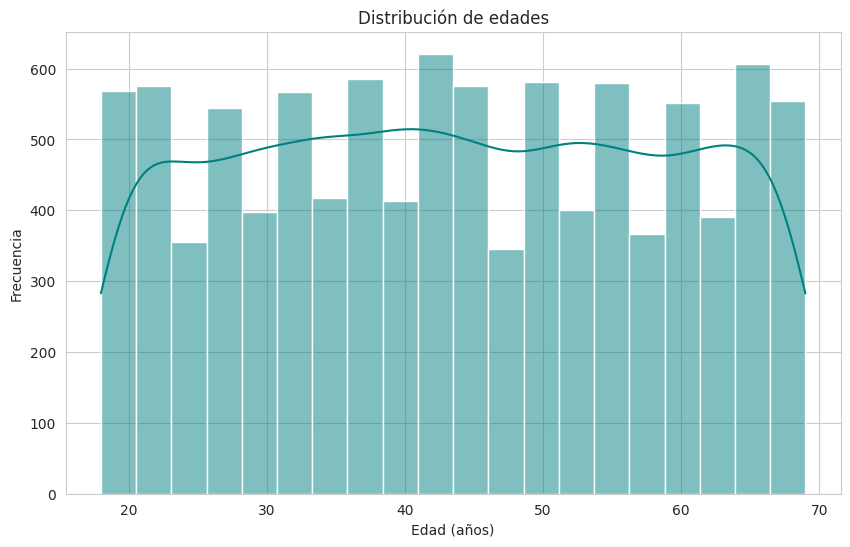

In [7]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="age", bins=20, kde=True, color="teal")
plt.title("Distribución de edades")
plt.xlabel("Edad (años)")
plt.ylabel("Frecuencia")
plt.show()

La distribución de edades aparenta ser relativamente uniforme, abarcando un rango amplio de valores. La curva KDE ayuda a visualizar la densidad de probabilidad estimada.

## Visualización 2: Boxplot de peso por sexo

Se compara la distribución del peso entre los grupos definidos por sexo.

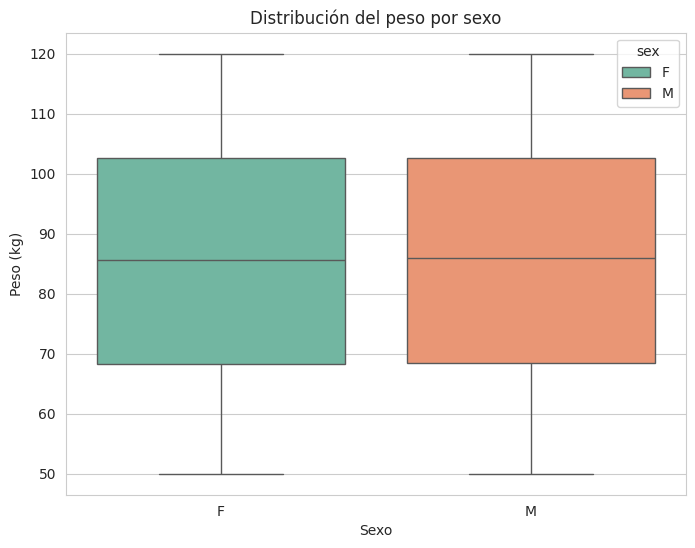

In [8]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="sex", y="weight", hue="sex", palette="Set2")
plt.title("Distribución del peso por sexo")
plt.xlabel("Sexo")
plt.ylabel("Peso (kg)")
plt.show()

El boxplot permite observar la mediana, cuartiles y posibles valores atípicos en el peso para cada categoría. Las diferencias entre grupos pueden indicar patrones en la composición del dataset.

## Visualización 3: Scatterplot de altura vs peso

Se explora la relación entre altura y peso, coloreando los puntos según el sexo.

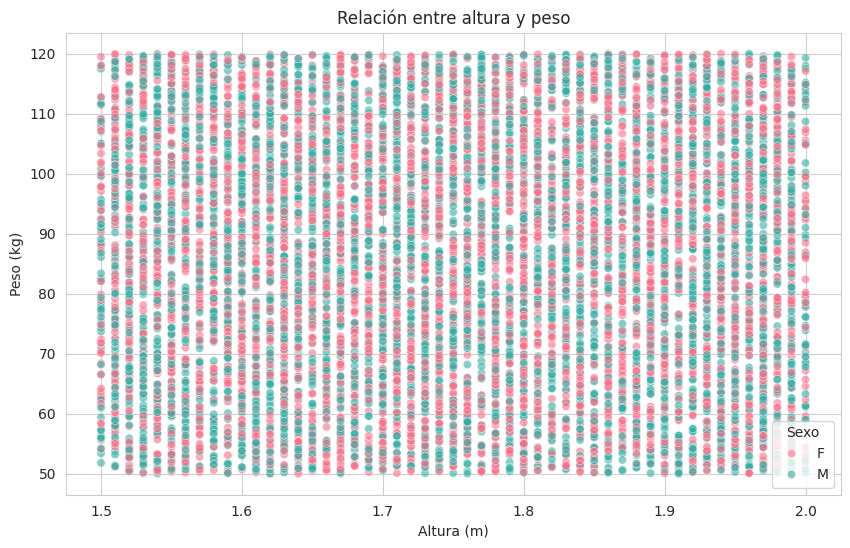

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="height", y="weight", hue="sex", alpha=0.6, palette="husl")
plt.title("Relación entre altura y peso")
plt.xlabel("Altura (m)")
plt.ylabel("Peso (kg)")
plt.legend(title="Sexo")
plt.show()

No se observa una correlación fuerte entre altura y peso en estos datos. Los puntos se distribuyen de forma dispersa sin un patrón lineal claro, lo cual puede deberse a la naturaleza sintética del dataset.

## Visualización 4: Heatmap de correlación

Se calcula y visualiza la matriz de correlación entre las variables numéricas.

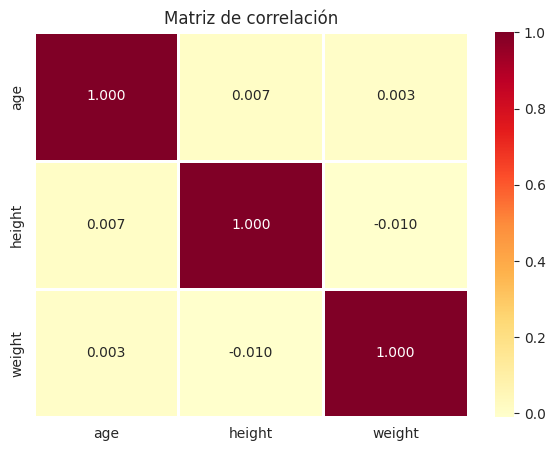

In [10]:
# Seleccionar columnas numéricas
cols_numericas = ["age", "height", "weight"]
matriz_corr = df[cols_numericas].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(matriz_corr, annot=True, cmap="YlOrRd", fmt=".3f", linewidths=1)
plt.title("Matriz de correlación")
plt.show()

Las correlaciones son prácticamente nulas entre las tres variables numéricas. Esto sugiere que edad, altura y peso son independientes entre sí en este conjunto de datos generado.

## Visualización 5: Pairplot de todas las variables numéricas

Se utiliza `sns.pairplot()` para obtener una vista general de las relaciones entre todas las variables numéricas, diferenciando por sexo.

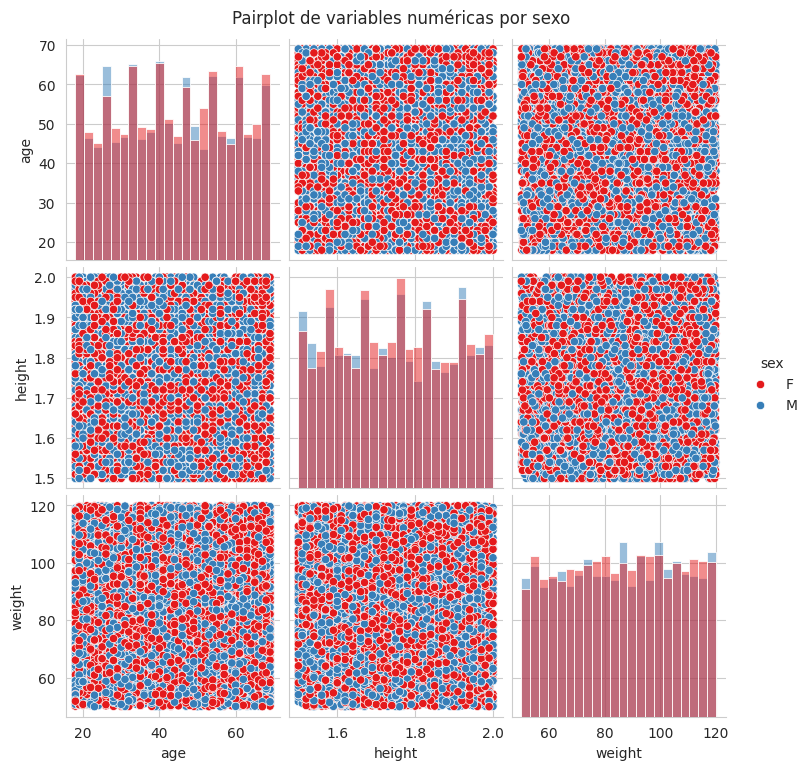

In [11]:
sns.pairplot(df[["age", "height", "weight", "sex"]], hue="sex", palette="Set1", diag_kind="hist")
plt.suptitle("Pairplot de variables numéricas por sexo", y=1.02)
plt.show()

El pairplot confirma visualmente la ausencia de correlaciones fuertes entre variables. Los histogramas diagonales muestran distribuciones similares entre grupos, y los scatterplots no revelan patrones de agrupamiento definidos.

## Visualización 6: LMplot - Regresión lineal de altura vs peso

Se utiliza `sns.lmplot()` para ajustar una línea de regresión entre altura y peso, separando por categoría.

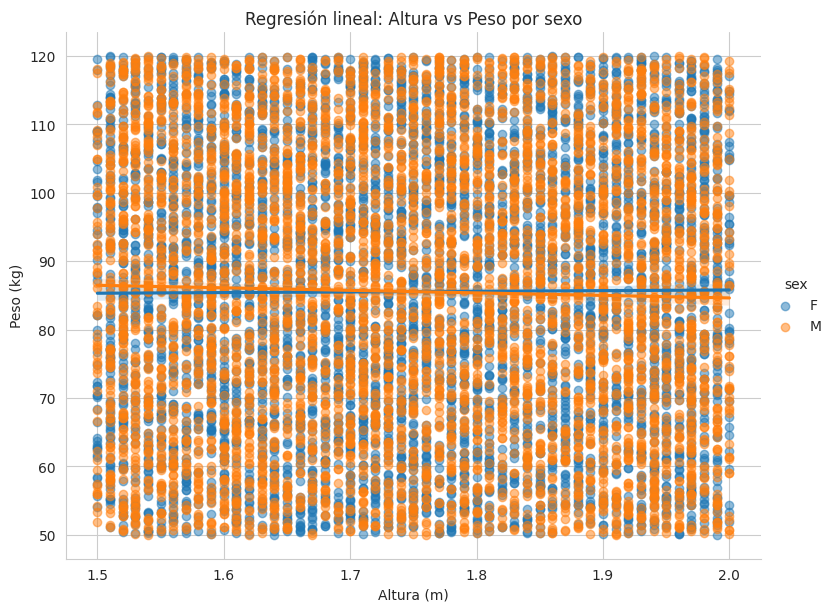

In [12]:
sns.lmplot(data=df, x="height", y="weight", hue="sex", height=6, aspect=1.3, scatter_kws={"alpha": 0.5})
plt.title("Regresión lineal: Altura vs Peso por sexo")
plt.xlabel("Altura (m)")
plt.ylabel("Peso (kg)")
plt.show()

Las líneas de regresión para ambos grupos son prácticamente horizontales, confirmando que no existe una relación lineal significativa entre altura y peso en este dataset. Las bandas de confianza son amplias debido a la alta dispersión.

## Visualización 7: Catplot - Distribución de edad por sexo

Se utiliza `sns.catplot()` para crear un gráfico de violín que muestra la distribución de edades según el sexo.

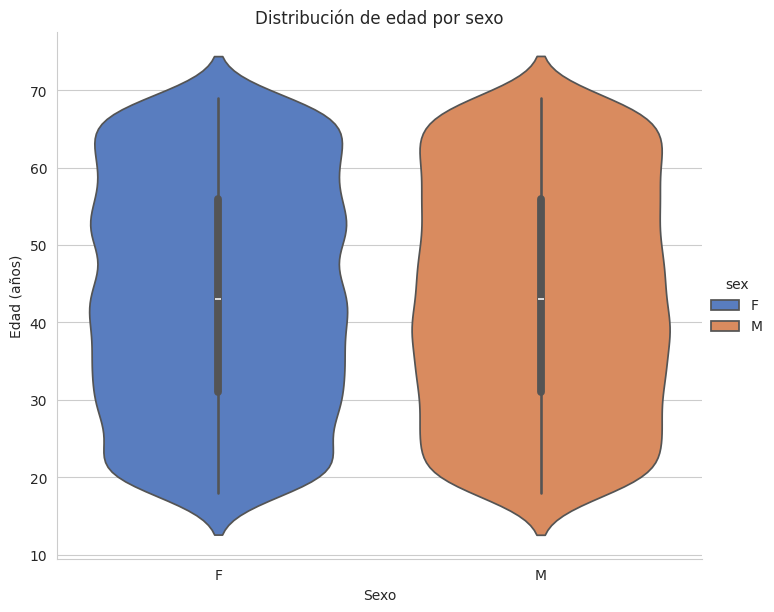

In [13]:
sns.catplot(data=df, x="sex", y="age", hue="sex", kind="violin", height=6, aspect=1.2, palette="muted")
plt.title("Distribución de edad por sexo")
plt.xlabel("Sexo")
plt.ylabel("Edad (años)")
plt.show()

Los gráficos de violín muestran distribuciones de edad similares para ambos grupos, con forma aproximadamente uniforme. No se detectan diferencias notables en la distribución etaria entre categorías.

## Resumen estadístico complementario

In [14]:
# Estadísticas agrupadas por sexo
resumen = df.groupby("sex")[["age", "height", "weight"]].agg(["mean", "std", "min", "max"])
resumen

age                           height                      \
          mean        std   min   max      mean       std  min  max   
sex                                                                   
F    43.694681  14.917644  18.0  69.0  1.749205  0.142984  1.5  2.0   
M    43.379080  14.910364  18.0  69.0  1.747336  0.145568  1.5  2.0   

        weight                          
          mean        std   min    max  
sex                                     
F    85.556456  20.080974  50.0  120.0  
M    85.548936  20.132661  50.0  120.0

## Conclusiones del EDA

El análisis exploratorio visual del dataset de personas ficticias permitió identificar las siguientes características:

1. Las distribuciones de edad, altura y peso son relativamente uniformes, sin sesgos marcados.

2. No se encontraron correlaciones significativas entre las variables numéricas, lo cual es consistente con datos generados aleatoriamente.

3. Las diferencias entre grupos (por sexo) son mínimas en términos de las métricas analizadas.

Este notebook puede utilizarse como plantilla para análisis exploratorios en datasets reales con estructuras que se le parezcan.